In [6]:
import numpy as np

# inputs
x = np.array([0.5, 0.2, 0.1])

# weights
w = np.array([0.4, -0.7, 0.2])

# weighted sum
y_sum = np.dot(x, w)

bias = 0.3

# weighted sum + bias
y_sum_b = y_sum + bias

# activation (identity function)
y_out = y_sum_b

print("Weighted Sum:", y_sum)
print("Weighted Sum + bias:", y_sum_b)
print("Output:", y_out)



Weighted Sum: 0.08000000000000003
Weighted Sum + bias: 0.38
Output: 0.38


In [7]:
def biological_neuron(signals, threshold=1.0):
    # Accumulation (soma)
    soma = sum(signals)

    # Check threshold
    if soma >= threshold:
        return 1   # neuron fires
    else:
        return 0   # neuron does not fire


signals = [0.3, 0.4, 0.5]

print("Neuron Output:", biological_neuron(signals))
print("Neuron Output:", biological_neuron(signals, threshold=1.3))

Neuron Output: 1
Neuron Output: 0


In [8]:
import numpy as np
def artificial_neuron(inputs, weights, bias=0):
    y_sum=np.dot(inputs,weights)+bias
    y_out=y_sum
    return y_out
x=np.array([1,0,1])
w=np.array([0.5,-0.6,0.2])
print("Summation output:",artificial_neuron(x,w,bias=0.1))


Summation output: 0.7999999999999999


In [9]:
import math
#identity function
def identity(x):
    return x

#Step function
def step(x):
    return 1 if x >= 0 else 0

#Threshold function
def threshold(x, theta=0.5):
    return 1 if x >= theta else 0

#ReLU function
def relu(x):
    return max(0,x)

#Sigmoid function
def sigmoid(x, k=1):
    return  1/(1+math.exp(-k *x))

#Bipolar sigmoid
def bipolar_sigmoid(x):
    return (2/(1+math.exp(-x)))+1

#Hyperbolic Tangent Function
def tanh_fn(x):
    return math.tanh(x)

values=[-2, -1, 0, 0.5, 1, 2]
print("Input Values: ",values)
print("identity(x): ")
for x in values:
    print(x,"->",identity(x))
    
print("step(x): ",values)
for x in values:
    print(x,"->",step(x))
print("Threshold function:",values)
for x in values:
    print(x,"->",threshold(x))
    
print("ReLU functon:",values)
for x in values:
    print(x,"->",relu(x))
    
print("Sigmoid function: ",values)
for x in values:
    print(x,"->",round(sigmoid(x),4))
    
print("Bipolr function: ",values)
for x in values:
    print(x,"->",round(bipolar_sigmoid(x),4))
    
print("Hyperbolic Tangent Function: ", values)
for x in values:
    print(x,"->",round(tanh_fn(x),4))

Input Values:  [-2, -1, 0, 0.5, 1, 2]
identity(x): 
-2 -> -2
-1 -> -1
0 -> 0
0.5 -> 0.5
1 -> 1
2 -> 2
step(x):  [-2, -1, 0, 0.5, 1, 2]
-2 -> 0
-1 -> 0
0 -> 1
0.5 -> 1
1 -> 1
2 -> 1
Threshold function: [-2, -1, 0, 0.5, 1, 2]
-2 -> 0
-1 -> 0
0 -> 0
0.5 -> 1
1 -> 1
2 -> 1
ReLU functon: [-2, -1, 0, 0.5, 1, 2]
-2 -> 0
-1 -> 0
0 -> 0
0.5 -> 0.5
1 -> 1
2 -> 2
Sigmoid function:  [-2, -1, 0, 0.5, 1, 2]
-2 -> 0.1192
-1 -> 0.2689
0 -> 0.5
0.5 -> 0.6225
1 -> 0.7311
2 -> 0.8808
Bipolr function:  [-2, -1, 0, 0.5, 1, 2]
-2 -> 1.2384
-1 -> 1.5379
0 -> 2.0
0.5 -> 2.2449
1 -> 2.4621
2 -> 2.7616
Hyperbolic Tangent Function:  [-2, -1, 0, 0.5, 1, 2]
-2 -> -0.964
-1 -> -0.7616
0 -> 0.0
0.5 -> 0.4621
1 -> 0.7616
2 -> 0.964


In [13]:
import matplotlib.pyplot as plt

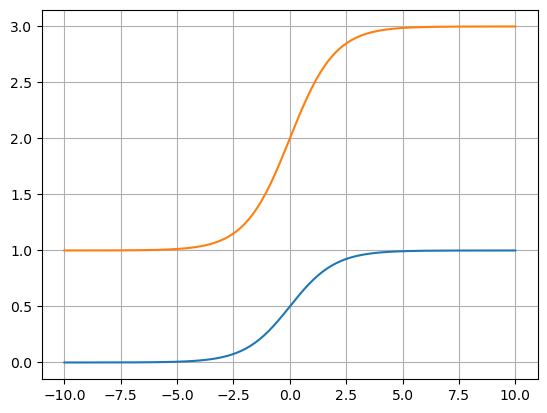

In [16]:
values = [-2, -1, 0, 0.5, 1, 2]
x=np.linspace(-10,10,200)
y=[]
y1=[]
for i in x:
    y.append(round(sigmoid(i),4))
    y1.append(round(bipolar_sigmoid(i),4))
plt.plot(x,y)
plt.plot(x,y1)
plt.grid()
plt.show()

In [23]:
def mcp_neuron(x1,x2,w1=1,w2=1,threshold=1):
    y_sum=x1*w1+x2*w2
    return 1 if y_sum>=threshold else 0
for x1 in [0,1]:
    for x2 in [0,1]:
        print(x1,x2,"->", mcp_neuron(x1,x2))

0 0 -> 0
0 1 -> 1
1 0 -> 1
1 1 -> 1


In [24]:
def mcp_neuron(x1,x2,w1=1,w2=1,threshold=1):
    y_sum=x1*w1+x2*w2
    return 0 if y_sum<=threshold else 1
for x1 in [0,1]:
    for x2 in [0,1]:
        print(x1,x2,"->", mcp_neuron(x1,x2))

0 0 -> 0
0 1 -> 0
1 0 -> 0
1 1 -> 1


In [46]:
import numpy as np

class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs

    def activation(self, x):
        return 1 if x >= 0 else -1

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            for i in range(len(X)):
                linear = np.dot(X[i], self.weights) + self.bias
                y_pred = self.activation(linear)

                update = self.lr * (y[i] - y_pred)
                self.weights += update * X[i]
                self.bias += update

    def predict(self, X):
        linear = np.dot(X, self.weights) + self.bias
        return (self.activation(linear))
        

X = np.array([
    [2,3],
    [1,1],
    [2,1],
    [-1,-2]
])
y = np.array([-1,-1,-1,1])
model = Perceptron()
model.fit(X,y)
predictions = model.predict([2,3])
print("Predictions:", predictions)

Predictions: -1


In [47]:
import numpy as np

class Adaline:

    def __init__(self, lr=0.01, epochs=20):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0

        for _ in range(self.epochs):
            for i in range(len(X)):
                y_sum = np.dot(X[i], self.weights) + self.bias
                error = y[i] - y_sum

                self.weights += self.lr * error * X[i]
                self.bias += self.lr * error

    def predict(self, X):
        y_sum = np.dot(X, self.weights) + self.bias
        return 1 if y_sum >= 0 else -1


X = np.array([[1,2], [2,3], [3,4], [-1,-2]])
y = np.array([1,1,1,-1])

a = Adaline()
a.fit(X, y)

for x in X:
    print(x, "->", a.predict(x))

[1 2] -> 1
[2 3] -> 1
[3 4] -> 1
[-1 -2] -> -1


In [1]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score

# Generate dataset
X, y = make_classification(n_samples=300,
                           n_features=4,
                           n_informative=4,
                           n_redundant=0,
                           random_state=1)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Deep Neural Network (3 hidden layers)
model = MLPClassifier(hidden_layer_sizes=(64, 32, 16),
                      activation='relu',
                      learning_rate_init=0.01,
                      max_iter=500)

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9444444444444444
